In [1]:
#Bibliotheken laden
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kde
from plotnine import *

In [2]:
#Daten laden
olympics = pd.read_csv("olympics.csv")

In [3]:
#Übersicht verschaffen
olympics

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [4]:
#Übersicht der Spalten
olympics.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [5]:
#Übersicht des Datensatzes
olympics.shape

(271116, 15)

In [6]:
#Statistik generieren -> auffällig ist, dass das Mindestalter von zehn Jahren uund Höchstalter von 97 Jahren
olympics.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


Es ist zu erkennen, dass die Höhe in cm und das Gewicht in Kilogramm gemessen wurden.

In [7]:
#Überprüfen der Nullwerte -> muss aber nicht zwingend Fehler beinhalten
olympics.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [8]:
#Datentypen überprüfen
olympics.dtypes

ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

# LE1 Visualization basics, chart types

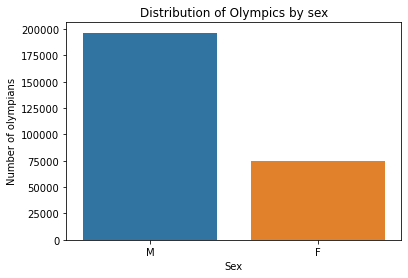

In [9]:
ax = sns.countplot(x='Sex', data=olympics)
plt.title('Distribution of Olympics by sex')
plt.ylabel('Number of olympians')
plt.show()

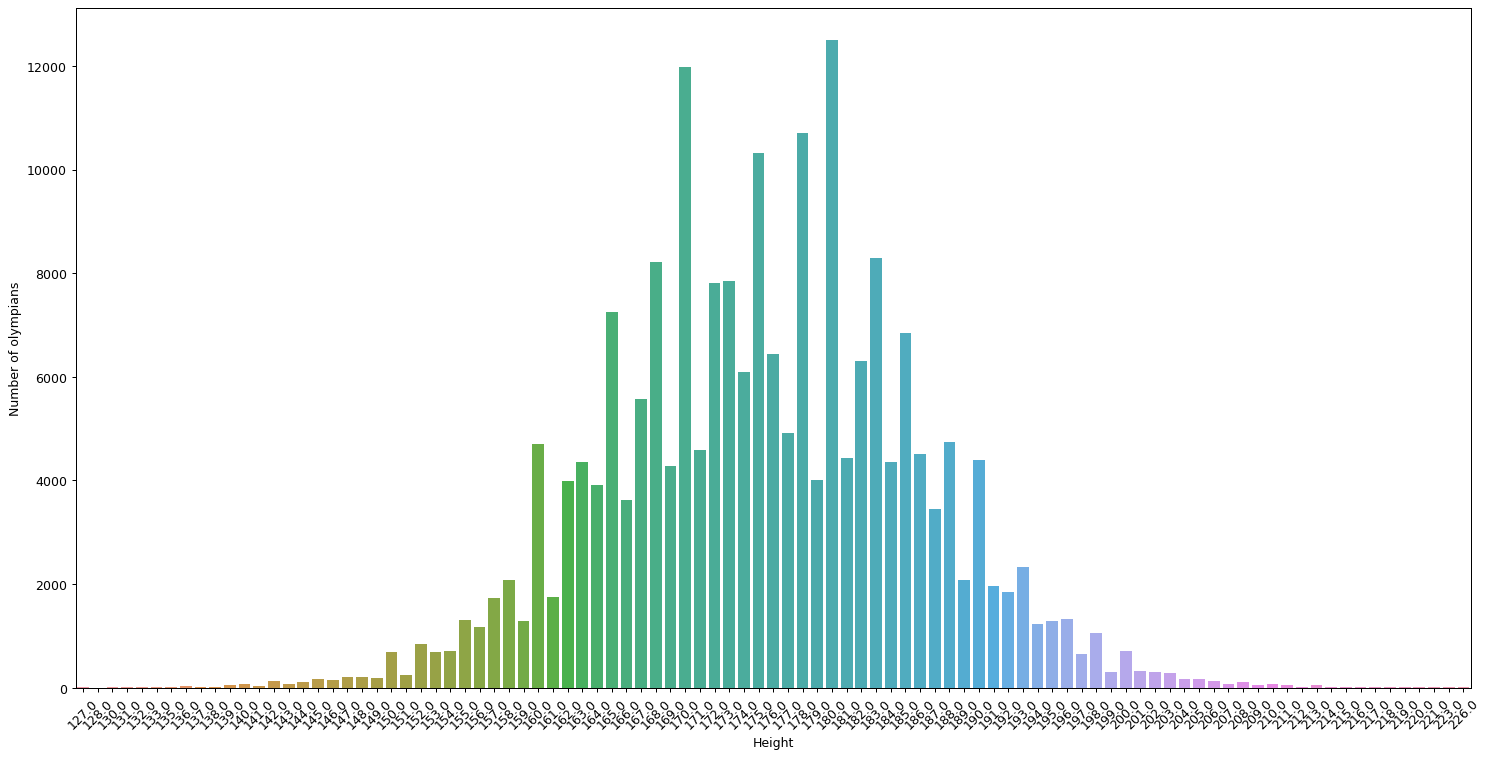

In [10]:
plt.figure(figsize=(20,10), dpi=90)
ax = sns.countplot(x='Height', data=olympics)
plt.xticks(rotation=45)
plt.xlabel('Height')
plt.ylabel('Number of olympians')
plt.show()

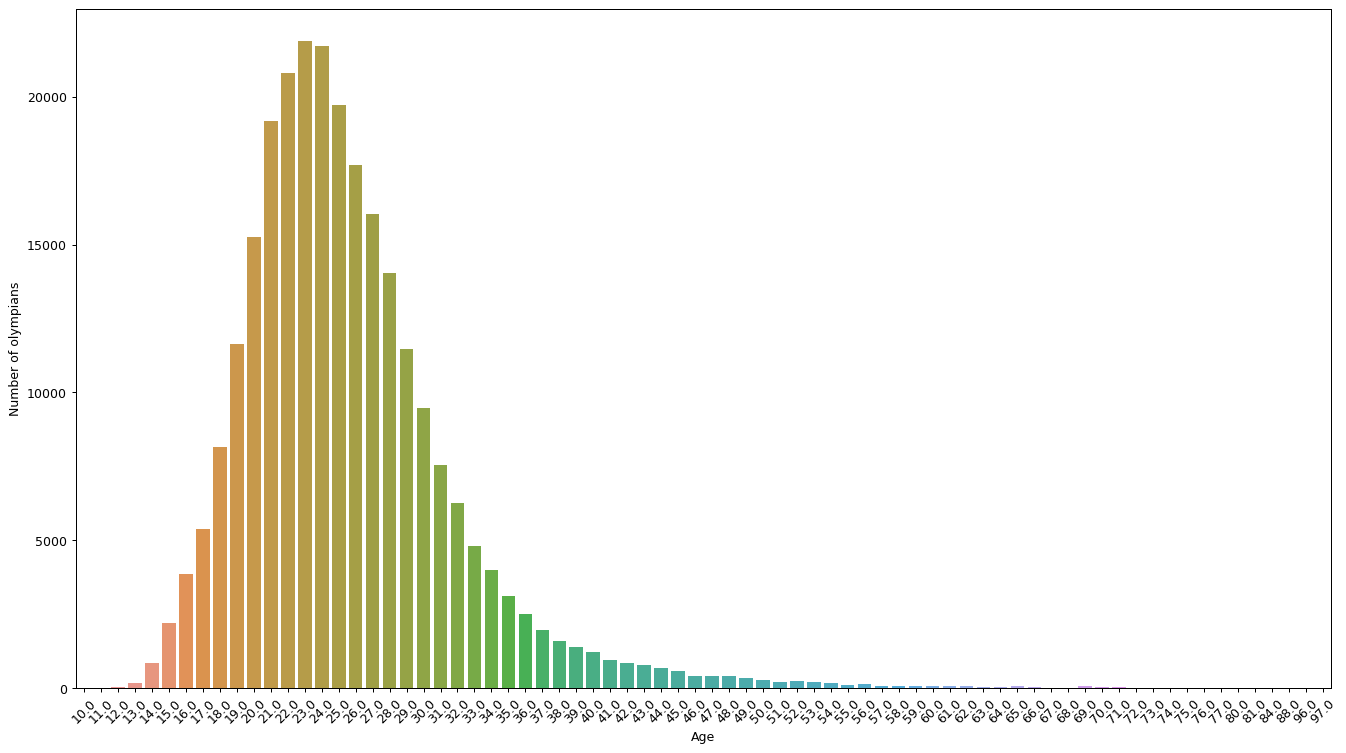

In [11]:
plt.figure(figsize=(18,10), dpi=90)
ax = sns.countplot(x='Age', data=olympics)
plt.xticks(rotation=45)
plt.xlabel('Age')
plt.ylabel('Number of olympians')
plt.show()

/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).


<AxesSubplot:xlabel='Age', ylabel='Density'>

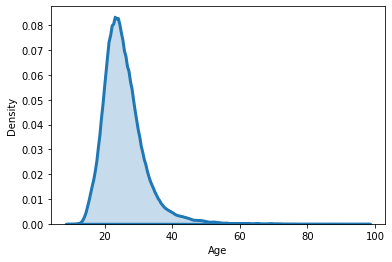

In [12]:
sns.distplot(olympics['Age'], hist = False, kde = True,
                 kde_kws = {'shade': True, 'linewidth': 3}, 
                  label = 'Sex')

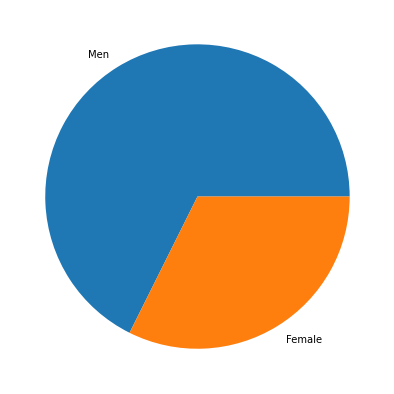

In [13]:
# Creating dataset
sex = ['Men', 'Female']
 
data = [139454, 66711]
 
# Creating plot
fig = plt.figure(figsize =(10, 7))
plt.pie(data, labels = sex)
 
# show plot
plt.show()

# LE2 Visual perception

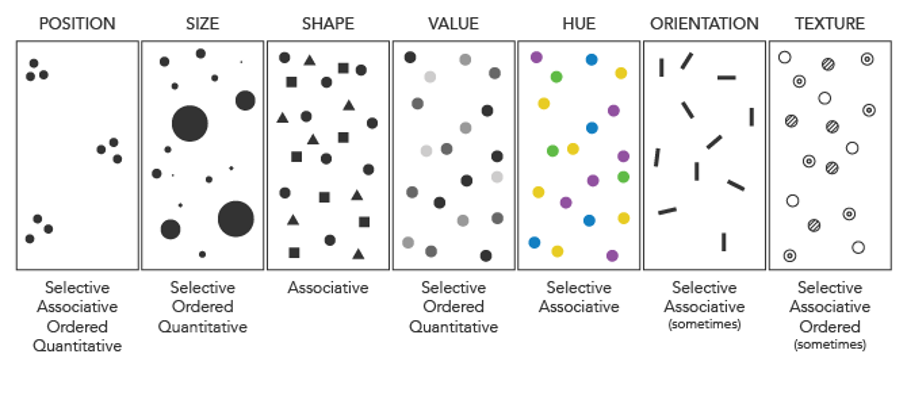

# LE3 Desing principles vs. data decisions 

In [14]:
# design principles
## layout
## alignment
## hierarchy
## proximity
## balance
## repitition
## color
## contrast
## negative space

# data decisions
## inspection
## cleaning
## verify
## reporting

# LE4 Grammar of Graphics

In [15]:
olympics_gymnastics = olympics[olympics['Sport'] == 'Gymnastics']

/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 1552 rows containing missing values.


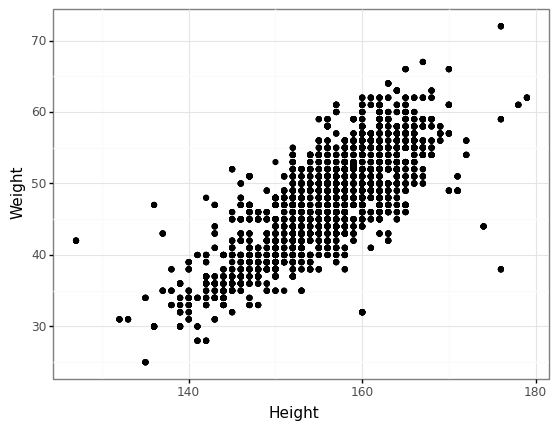

<ggplot: (8762825592769)>

In [16]:
#Visualize two-dimensions (2-D)
(ggplot(olympics_gymnastics[olympics_gymnastics['Sex']=='F'], 
        aes('Height', 'Weight')) 
        + geom_point()
        + theme_bw())

/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 1552 rows containing missing values.


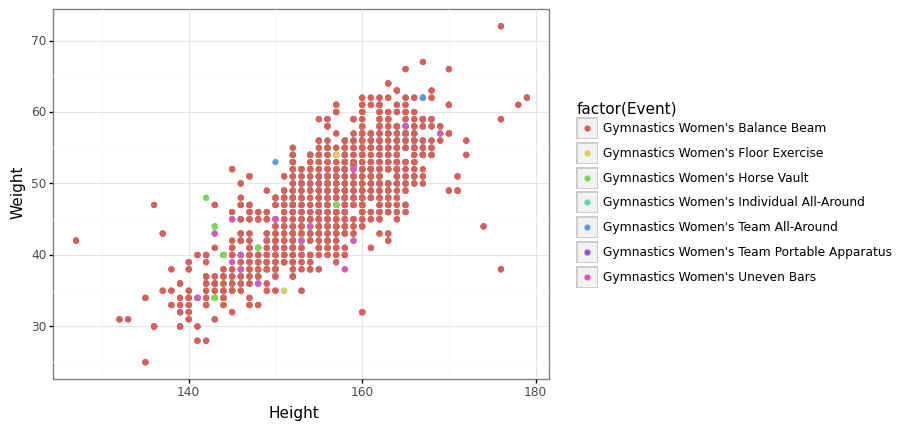

<ggplot: (8762825662522)>

In [17]:
#Visualize three-dimensions (3-D)
(ggplot(olympics_gymnastics[olympics_gymnastics['Sex']=='F'], 
        aes('Height', 'Weight', color='factor(Event)'))
        + geom_point()
        + theme_bw())

/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/scales/scale_size.py:48: PlotnineWarning: Using size for a discrete variable is not advised.
/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 8621 rows containing missing values.
/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/guides/guides.py:261: PlotnineWarning: geom_point legend : Removed 1 rows containing missing values.


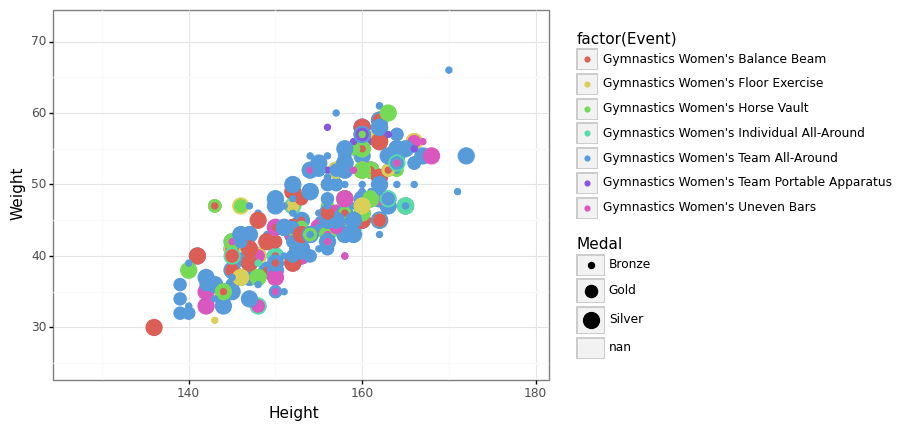

<ggplot: (8762825641436)>

In [18]:
#Visualize four-dimensions (4-D)
(ggplot(olympics_gymnastics[olympics_gymnastics['Sex']=='F'], 
        aes('Height', 'Weight',
            color='factor(Event)', size = 'Medal'))
        + geom_point()
        + theme_bw())

/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/scales/scale_size.py:48: PlotnineWarning: Using size for a discrete variable is not advised.
/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 25546 rows containing missing values.
/Users/nicko/opt/anaconda3/lib/python3.8/site-packages/plotnine/guides/guides.py:261: PlotnineWarning: geom_point legend : Removed 1 rows containing missing values.


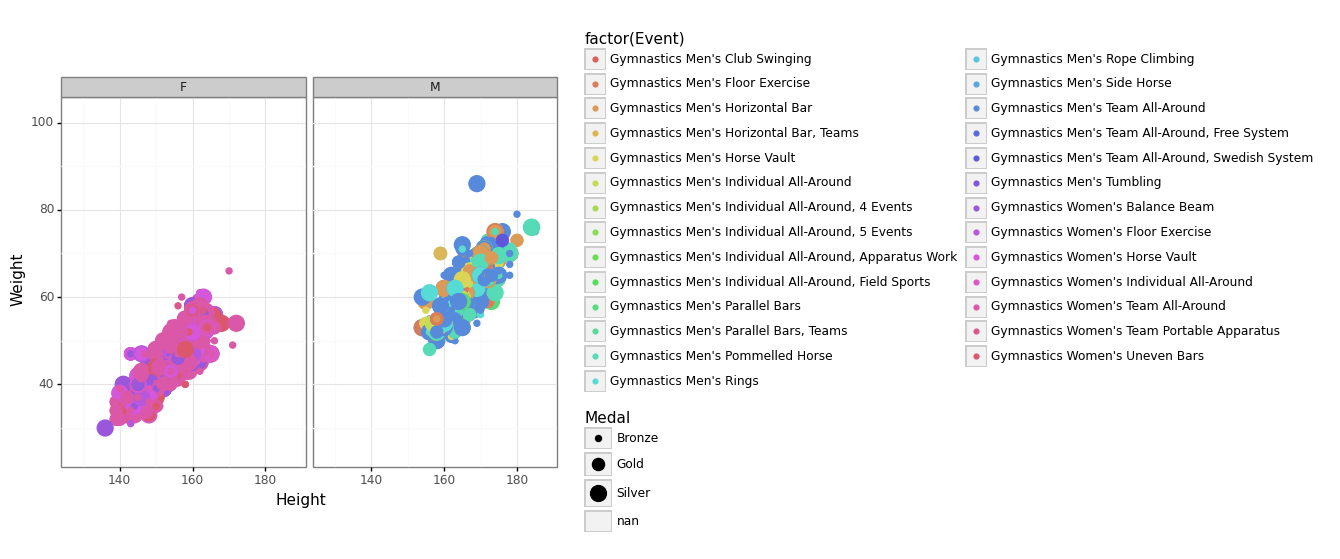

<ggplot: (8762773824124)>

In [19]:
#Visualize five-dimensions (5-D)
(ggplot(olympics_gymnastics,  
        aes('Height', 'Weight', 
            color='factor(Event)', 
            size='Medal'))
        + geom_point() 
        + facet_wrap('~Sex') 
        + theme_bw())

# LE5 Evaluation

<Figure size 1008x504 with 0 Axes>

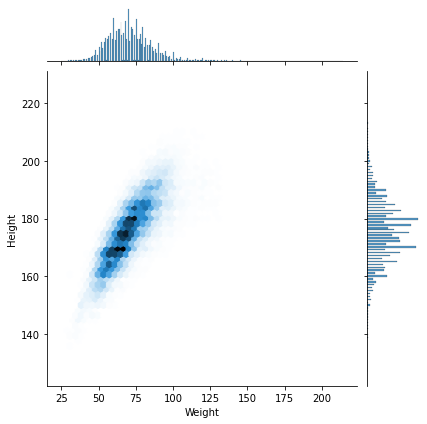

In [20]:
plt.figure(figsize=(14,7))
ax = sns.jointplot(y='Height', x='Weight', data=olympics, kind='hex')
plt.show()

(140.0, 210.0)

<Figure size 1008x504 with 0 Axes>

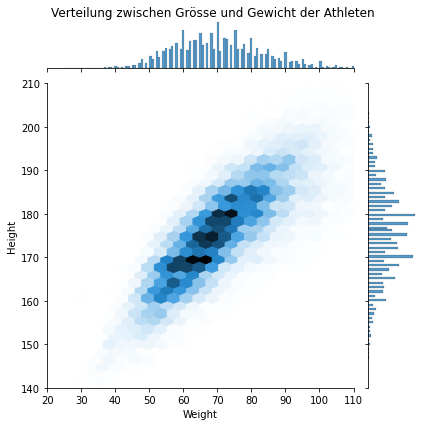

In [21]:
plt.figure(figsize=(14,7))
ax = sns.jointplot(y='Height', x='Weight', data=olympics, kind='hex')
ax.fig.suptitle("Verteilung zwischen Grösse und Gewicht der Athleten")
ax.fig.tight_layout()
ax.fig.subplots_adjust(top=0.95) # Reduce plot to make room
ax.ax_marg_x.set_xlim(20, 110)
ax.ax_marg_y.set_ylim(140, 210)

# diverse Plots

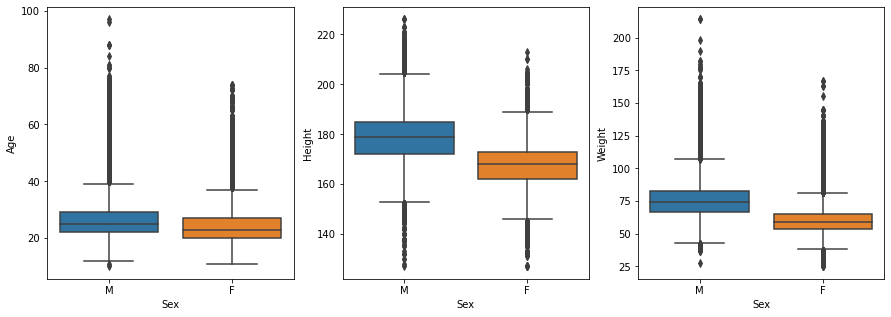

In [22]:
f, axes = plt.subplots(1, 3)
f.set_size_inches(15, 5)
sns.boxplot(x='Sex', y='Age', data=olympics, ax=axes[0])
sns.boxplot(x='Sex', y='Height', data=olympics, ax=axes[1])
sns.boxplot(x='Sex', y='Weight', data=olympics, ax=axes[2])
plt.show()

Wie man in den obigen Boxplots sehen kann, gibt es viele Ausreisser. Die Olympischen Spiele zeichnen sich durch eine grosse Vielfalt an Disziplinen aus, daher sind solche erheblichen Abweichungen gerechtfertigt. Wie auch immer, wir werden uns auf dieses Thema im weiteren Teil des Notizbuchs konzentrieren.

Das Diagramm zeigt uns, dass das Durchschnittsalter der Männer höher ist als das Durchschnittsalter der Frauen. Frauen sind durchschnittlich grösser als Männer und ihr Durchschnittsgewicht ist auch geringer als das Männergewicht.

In [23]:
max_age = olympics['Age'].max()
min_age = olympics['Age'].min()
olympics.loc[olympics['Age'].isin([min_age, max_age])]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
142882,71691,Dimitrios Loundras,M,10.0,NaN,NaN,Ethnikos Gymnastikos Syllogos,GRE,1896 Summer,1896,Summer,Athina,Gymnastics,"Gymnastics Men's Parallel Bars, Teams",Bronze
257054,128719,John Quincy Adams Ward,M,97.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",NaN


Wie wir aus dem oberen Rahmen sehen können, war Dimitrios Loundras der jüngste Olympiateilnehmer, der an den Olympischen Spielen 1896 teilnahm. Der älteste Olympiateilnehmer war der 97-jährige John Quincy Adams Ward, der an den Olympischen Spielen 1928 teilnahm.

https://en.wikipedia.org/wiki/Dimitrios_Loundras

https://en.wikipedia.org/wiki/John_Quincy_Adams_Ward

In [24]:
min_height = olympics['Height'].min()
max_height = olympics['Height'].max()
olympics.loc[olympics['Height'].isin([min_height,max_height])]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
29333,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Individual All-Around,NaN
29334,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Team All-Around,NaN
29335,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Floor Exercise,NaN
29336,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Horse Vault,NaN
29337,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Uneven Bars,NaN
29338,15150,Rosario Briones,F,15.0,127.0,42.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Gymnastics,Gymnastics Women's Balance Beam,NaN
164821,82769,Lyton Levison Mphande,M,25.0,127.0,62.0,Malawi,MAW,1988 Summer,1988,Summer,Seoul,Boxing,Boxing Men's Light-Welterweight,NaN
265040,132627,Yao Ming,M,20.0,226.0,141.0,China,CHN,2000 Summer,2000,Summer,Sydney,Basketball,Basketball Men's Basketball,NaN
265041,132627,Yao Ming,M,23.0,226.0,141.0,China,CHN,2004 Summer,2004,Summer,Athina,Basketball,Basketball Men's Basketball,NaN
265042,132627,Yao Ming,M,27.0,226.0,141.0,China,CHN,2008 Summer,2008,Summer,Beijing,Basketball,Basketball Men's Basketball,NaN


Die kleinste Olympiateilnehmerin war Rosario Briones mit einer Körpergrösse 127 cm. Sie war 15 Jahre alt, daher war ihre Grösse für dieses Alter normal. Der grösste Olympiateilnehmer war Yao Ming mit 226 cm Körpergröße, der Basketball spielte.

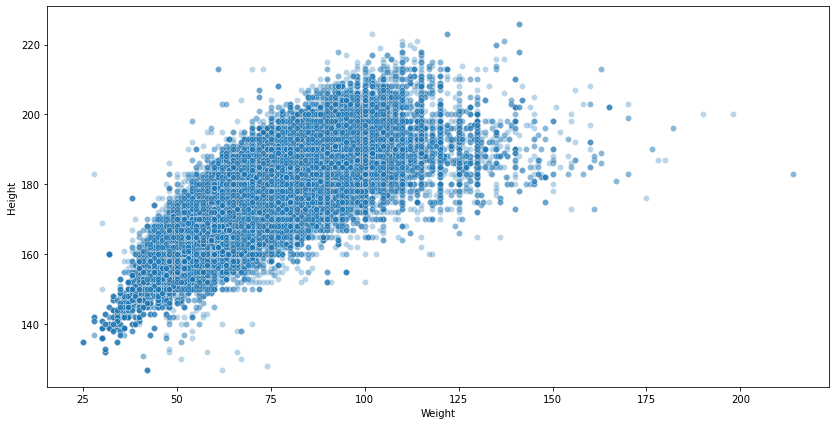

In [25]:
plt.figure(figsize=(14,7))
ax = sns.scatterplot(y='Height', x='Weight', data=olympics, alpha=0.3)
plt.show()

In [26]:
olympics[['Weight', 'Height']].corr()

,Weight,Height
Weight,1.000000,0.796213
Height,0.796213,1.000000


Aus dem Diagramm können wir annehmen, dass das Gewicht von der Körpergrösse abhängt. Pearsons Korrelation bestätigt meine Annahmen. Es gibt eine positive Korrelation zwischen Gewicht und Grösse.

In [27]:
#Neuer Datensatz anhand Teilmenge erstellt
#Sport in Summer Olympics:
Sport_Count=olympics.groupby('Sport').apply(lambda x:x['Year'].unique()).to_frame().reset_index()
Sport_Count.columns=['Sport','Years']
Sport_Count['Count']=[len(c) for c in Sport_Count['Years']]

In [28]:
Sport_Count = Sport_Count.sort_values(by='Count', ascending=False)

In [29]:
#Übersicht der ersten zehn Zeilen
Sport_Count.head(10)

,Sport,Years,Count
27,Gymnastics,"[1948, 1952, 1920, 2016, 1900, 1960, 2000, 197...",29
5,Athletics,"[1932, 2000, 1936, 1912, 2012, 1920, 1924, 192...",29
22,Fencing,"[1912, 2008, 2004, 1968, 1992, 1948, 1952, 193...",29
19,Cycling,"[1956, 1924, 2004, 2000, 2016, 1972, 1980, 198...",29
54,Swimming,"[1952, 1912, 1920, 1924, 1996, 2000, 1936, 200...",29
65,Wrestling,"[2000, 2004, 1992, 1996, 1964, 2012, 1948, 198...",28
43,Rowing,"[1996, 2000, 2016, 2012, 1984, 1988, 1992, 198...",28
20,Diving,"[2000, 1952, 2016, 1936, 1948, 2008, 2012, 198...",27
47,Shooting,"[1936, 1948, 1952, 1956, 1960, 1992, 1984, 200...",27
24,Football,"[1920, 1996, 1960, 2000, 2004, 2008, 1928, 190...",27


In [30]:
#Übersicht der letzten zehn Zeilen
Sport_Count.tail(10)

,Sport,Years,Count
45,Rugby Sevens,[2016],1
42,Roque,[1904],1
40,Racquets,[1908],1
37,Motorboating,[1908],1
35,Military Ski Patrol,[1924],1
31,Jeu De Paume,[1908],1
16,Croquet,[1900],1
15,Cricket,[1900],1
9,Basque Pelota,[1900],1
0,Aeronautics,[1936],1


In [31]:
sports = olympics[olympics['Sport'].isin(Sport_Count.Sport[:10])]

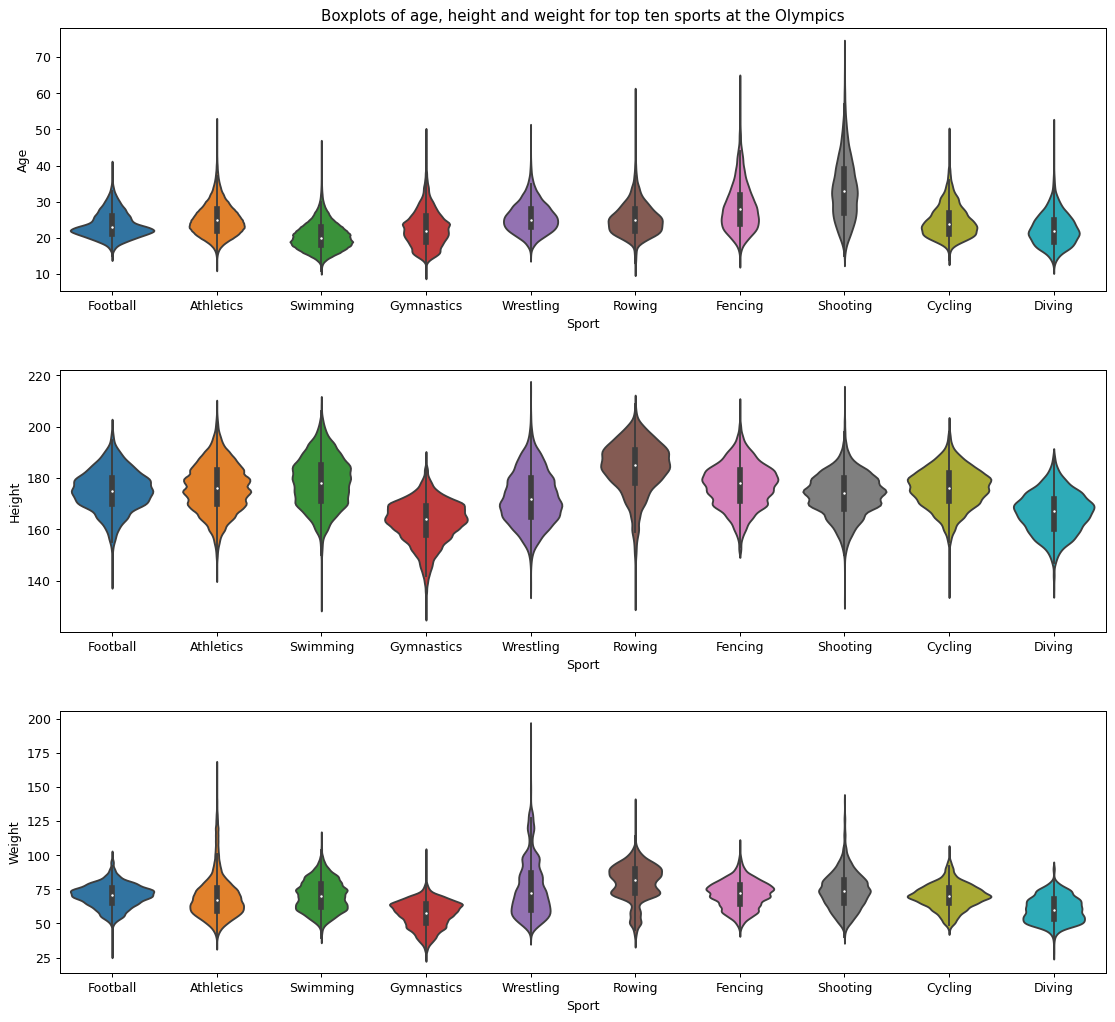

In [32]:
plt.figure(figsize=(15,12), dpi=90)

plt.subplot(311)
plt.title('Boxplots of age, height and weight for top ten sports at the Olympics')
ax=sns.violinplot(x='Sport',y='Age',data=sports)

plt.subplot(312)
ax=sns.violinplot(x='Sport',y='Height',data=sports)

plt.subplot(313)
ax=sns.violinplot(x='Sport',y='Weight',data=sports)

plt.subplots_adjust(wspace = 1, hspace = 0.3,top = 1)

plt.show()

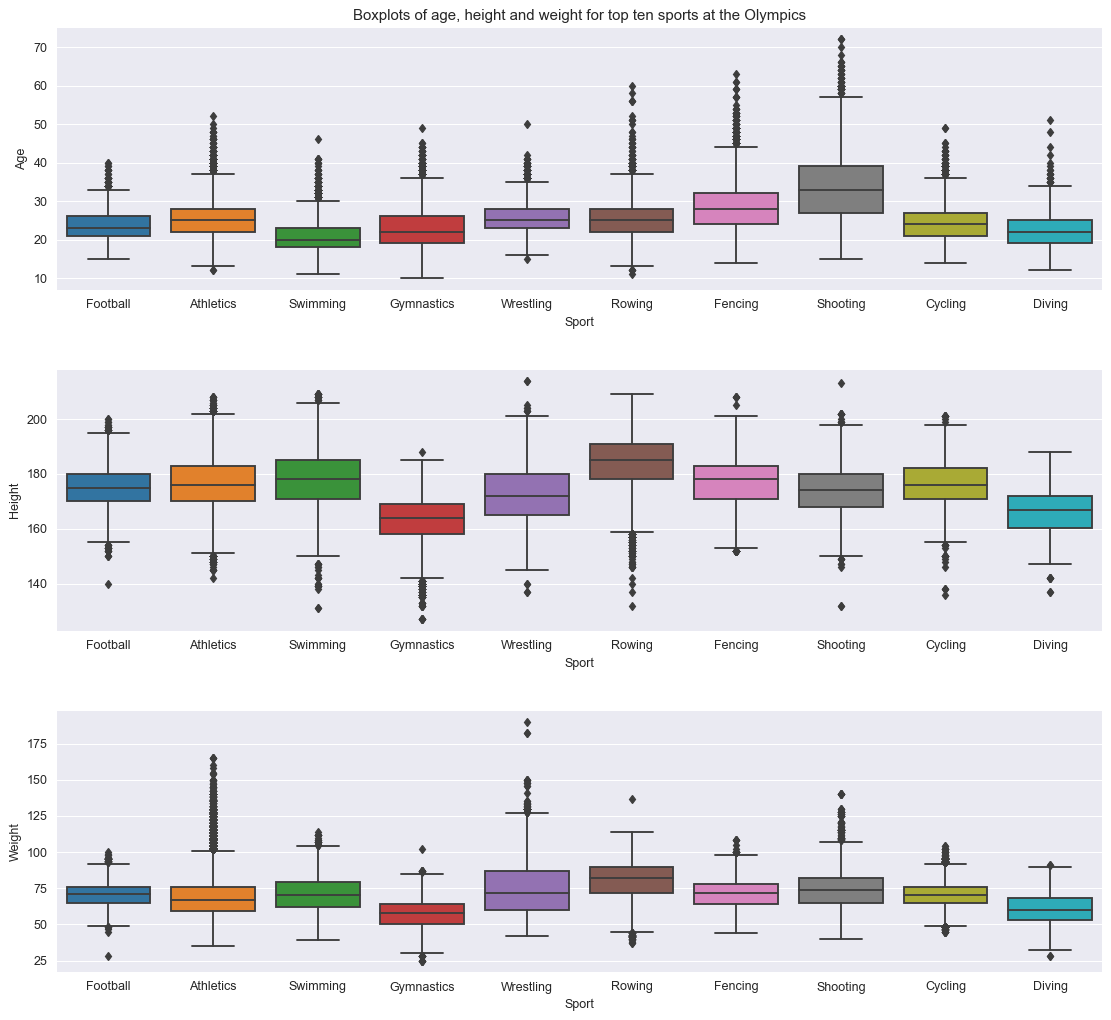

In [33]:
plt.figure(figsize=(15,12), dpi=90)

sns.set_style('darkgrid')

plt.subplot(311)
plt.title('Boxplots of age, height and weight for top ten sports at the Olympics')
ax=sns.boxplot(x='Sport',y='Age',data=sports)

plt.subplot(312)
ax=sns.boxplot(x='Sport',y='Height',data=sports)

plt.subplot(313)
ax=sns.boxplot(x='Sport',y='Weight',data=sports)

plt.subplots_adjust(wspace = 1, hspace = 0.3,top = 1)

Die Sportart Schiesssen zeichnet sich unter anderen Sportarten durch das höchste Alter aus. Turnen zeichnet sich unter anderen Sportarten durch die geringste Körpergrösse und auch das geringste Gewicht aus. Es scheint logisch, weil eine Person agil sein muss, daher ist ein geringes Gewicht ein wünschenswertes Merkmal.

In [34]:
#Eigenschaften der Medaillen untersuchen
medals_by_year = olympics.groupby(['Year', 'Medal'])['Medal'].count()
medals_by_year = medals_by_year.reset_index(level=[1], name='Count')

In [35]:
#Übersicht verschaffen
medals_by_year.head()

,Medal,Count
Year,,
1896,Bronze,38
1896,Gold,62
1896,Silver,43
1900,Bronze,175
1900,Gold,201


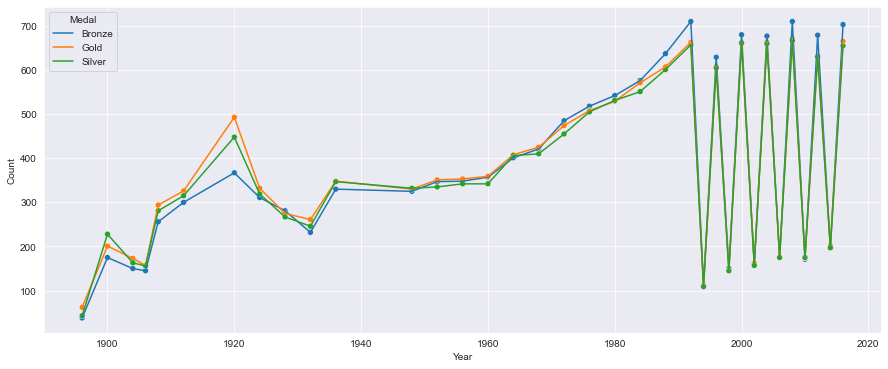

In [36]:
plt.figure(figsize=(15,6))
sns.set_style('darkgrid')
ax = sns.scatterplot(x=medals_by_year.index, y='Count', hue='Medal', data=medals_by_year, legend=False)
ax = sns.lineplot(x=medals_by_year.index, y='Count', hue='Medal', data=medals_by_year)
plt.show()

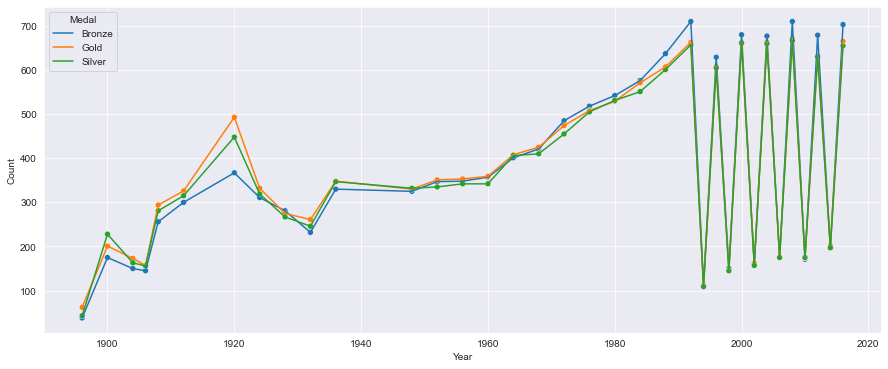

In [37]:
plt.figure(figsize=(15,6))
sns.set_style('darkgrid')
ax = sns.scatterplot(x=medals_by_year.index, y='Count', hue='Medal', data=medals_by_year, legend=False)
ax = sns.lineplot(x=medals_by_year.index, y='Count', hue='Medal', data=medals_by_year)
plt.show()